In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df=pd.read_csv("/content/drive/MyDrive/Executive_Hotel_Booking_EDA_Dataset.csv")

In [ ]:
df.head()

,Booking_ID,Hotel_Type,Hotel_Location,Booking_Date,Arrival_Date,Lead_Time_Days,Weekend_Nights,Weekday_Nights,Adults,Children,...,Meal_Type,Total_Nights,ADR,Required_Car_Parking_Spaces,Total_Special_Requests,Satisfaction_Score,Reservation_Status,Is_Canceled,Reservation_Status_Date,Estimated_Revenue
0,HTL024548,City Hotel,London,2024-07-29,2025-07-04,340,2,2,2,0.0,...,HB,4,178.66,0,1,4.37,No-Show,1,2025-07-07,714.65
1,HTL019878,City Hotel,London,2024-05-28,2025-02-08,256,1,2,2,2.0,...,Undefined,3,125.81,0,0,3.63,Canceled,1,2025-02-09,377.43
2,HTL017377,City Hotel,Lisbon,2024-05-10,2024-06-20,41,1,1,4,0.0,...,FB,2,148.03,0,0,3.70,Check-Out,0,2024-06-20,296.06
3,HTL003352,City Hotel,Lisbon,2024-03-15,2024-04-07,23,0,2,2,0.0,...,HB,2,166.82,0,3,3.18,Check-Out,0,2024-04-08,333.63
4,HTL012521,City Hotel,London,2024-08-21,2025-05-30,282,0,3,4,0.0,...,HB,3,76.83,0,1,3.79,Check-Out,0,2025-06-01,230.50


In [ ]:
# to Check the number of rows and columns
df.shape

(25180, 35)

In [ ]:
# The dataset contains 25,180 booking records and 35 columns.

In [ ]:
# to Display all column names in the dataset
df.columns

Index(['Booking_ID', 'Hotel_Type', 'Hotel_Location', 'Booking_Date',
       'Arrival_Date', 'Lead_Time_Days', 'Weekend_Nights', 'Weekday_Nights',
       'Adults', 'Children', 'Babies', 'Country', 'Market_Segment',
       'Distribution_Channel', 'Is_Repeated_Guest', 'Previous_Cancellations',
       'Previous_Bookings', 'Room_Type_Reserved', 'Room_Type_Assigned',
       'Booking_Changes', 'Deposit_Type', 'Agent_ID', 'Company_ID',
       'Days_In_Waiting_List', 'Customer_Type', 'Meal_Type', 'Total_Nights',
       'ADR', 'Required_Car_Parking_Spaces', 'Total_Special_Requests',
       'Satisfaction_Score', 'Reservation_Status', 'Is_Canceled',
       'Reservation_Status_Date', 'Estimated_Revenue'],
      dtype='object')

In [ ]:
# to display dataset structure, non-null values, and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25180 entries, 0 to 25179
Data columns (total 35 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Booking_ID                   25180 non-null  object 
 1   Hotel_Type                   25180 non-null  object 
 2   Hotel_Location               25074 non-null  object 
 3   Booking_Date                 25180 non-null  object 
 4   Arrival_Date                 25180 non-null  object 
 5   Lead_Time_Days               25180 non-null  int64  
 6   Weekend_Nights               25180 non-null  int64  
 7   Weekday_Nights               25180 non-null  int64  
 8   Adults                       25180 non-null  int64  
 9   Children                     25059 non-null  float64
 10  Babies                       25180 non-null  int64  
 11  Country                      24714 non-null  object 
 12  Market_Segment               25180 non-null  object 
 13  Distribution_Cha

In [ ]:
# Generate descriptive statistics for numerical columns
df.describe()

,Lead_Time_Days,Weekend_Nights,Weekday_Nights,Adults,Children,Babies,Is_Repeated_Guest,Previous_Cancellations,Previous_Bookings,Booking_Changes,Agent_ID,Company_ID,Days_In_Waiting_List,Total_Nights,ADR,Required_Car_Parking_Spaces,Total_Special_Requests,Satisfaction_Score,Is_Canceled,Estimated_Revenue
count,25180.000000,25180.000000,25180.000000,25180.000000,25059.000000,25180.000000,25180.000000,25180.000000,25180.000000,25180.000000,24876.000000,4451.000000,25180.000000,25180.000000,25098.000000,25180.000000,25180.000000,25016.000000,25180.000000,25180.000000
mean,182.200556,1.240429,2.451072,2.198967,0.372122,0.043050,0.172597,0.038642,1.117037,0.601191,89.698866,1059.135700,1.561438,3.693090,140.628124,0.228753,1.097458,3.854402,0.721763,535.495478
std,105.604452,1.063802,2.031003,0.662379,0.657811,0.225057,0.377906,0.251403,2.829046,0.894293,51.731839,34.270543,4.459498,2.085623,47.808034,0.530060,1.047671,0.405110,0.448140,389.700003
min,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1001.000000,0.000000,1.000000,30.800000,0.000000,0.000000,0.300000,0.000000,31.820000
25%,91.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,45.000000,1029.000000,0.000000,2.000000,105.620000,0.000000,0.000000,3.590000,0.000000,230.540000
50%,182.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,89.000000,1059.000000,0.000000,4.000000,134.425000,0.000000,1.000000,3.860000,1.000000,448.735000
75%,273.000000,2.000000,4.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,135.000000,1088.000000,1.000000,5.000000,169.097500,0.000000,2.000000,4.130000,1.000000,737.577500
max,920.000000,3.000000,13.000000,7.000000,6.000000,2.000000,1.000000,3.000000,12.000000,4.000000,179.000000,1119.000000,180.000000,45.000000,710.500000,3.000000,5.000000,5.900000,1.000000,3256.020000


In [ ]:
# Generate summary statistics for categorical columns
df.describe(include='object')

,Booking_ID,Hotel_Type,Hotel_Location,Booking_Date,Arrival_Date,Country,Market_Segment,Distribution_Channel,Room_Type_Reserved,Room_Type_Assigned,Deposit_Type,Customer_Type,Meal_Type,Reservation_Status,Reservation_Status_Date
count,25180,25180,25074,25180,25180,24714,25180,25180,25180,25180,25180,25180,24935,25180,25180
unique,25000,5,11,731,1073,24,8,3,8,8,3,4,9,3,1076
top,HTL014830,City Hotel,Dubai,2025-12-10,2026-01-02,BRA,Online TA,TA/TO,D,C,Non Refund,Contract,BB,Canceled,2025-02-26
freq,2,15606,3171,58,54,1158,10782,17010,3227,3218,12485,6446,5027,16723,55


In [ ]:
# to count missing values in each column
df.isnull().sum()

,0
Booking_ID,0
Hotel_Type,0
Hotel_Location,106
Booking_Date,0
Arrival_Date,0
Lead_Time_Days,0
Weekend_Nights,0
Weekday_Nights,0
Adults,0
Children,121


In [ ]:
# Observations:
#Missing values are present in multiple columns, but they are not evenly distributed.
# Some variables have only a small number of missing records, whereas Company_ID has a very large number of missing values.
# This suggests that different columns may require different treatment rather than applying one missing-value strategy to the entire dataset.

In [ ]:
# to calculate missing value count and percentage
missing_values =pd.DataFrame({
    "missing_count" : df.isnull().sum(),
    "missing_percentage" : df.isnull().mean()*100 # .sum()/len(df)*100
 })

In [ ]:
missing_values

,missing_count,missing_percentage
Booking_ID,0,0.000000
Hotel_Type,0,0.000000
Hotel_Location,106,0.420969
Booking_Date,0,0.000000
Arrival_Date,0,0.000000
Lead_Time_Days,0,0.000000
Weekend_Nights,0,0.000000
Weekday_Nights,0,0.000000
Adults,0,0.000000
Children,121,0.480540


In [ ]:
missing_values=missing_values[
    missing_values["missing_count"]>0
]

In [ ]:
missing_values

,missing_count,missing_percentage
Hotel_Location,106,0.420969
Children,121,0.480540
Country,466,1.850675
Agent_ID,304,1.207307
Company_ID,20729,82.323272
Meal_Type,245,0.972994
ADR,82,0.325655
Satisfaction_Score,164,0.651311


In [ ]:
missing_values=missing_values.sort_values(
    by="missing_percentage",
    ascending=False
)

In [ ]:
missing_values

,missing_count,missing_percentage
Company_ID,20729,82.323272
Country,466,1.850675
Agent_ID,304,1.207307
Meal_Type,245,0.972994
Satisfaction_Score,164,0.651311
Children,121,0.480540
Hotel_Location,106,0.420969
ADR,82,0.325655


In [ ]:
# Observation:
# The missing-value analysis shows that Company_ID has exceptionally high missingness compared with the other variables.

In [ ]:
# to count completely duplicated rows
df.duplicated().sum()

np.int64(180)

In [ ]:
#Observations:
#The dataset contains 180 completely duplicated records.
#If these records are left unchanged, they could cause certain bookings to be counted more than once.

In [ ]:
# to check for duplicate booking IDs
df['Booking_ID'].duplicated().sum()

np.int64(180)

In [ ]:
# Display the data type of every column
df.dtypes

,0
Booking_ID,object
Hotel_Type,object
Hotel_Location,object
Booking_Date,object
Arrival_Date,object
Lead_Time_Days,int64
Weekend_Nights,int64
Weekday_Nights,int64
Adults,int64
Children,float64


In [ ]:
# to check unique values in the hotel type column
df['Hotel_Type'].unique()

array(['City Hotel', 'Resort Hotel', 'CITY HOTEL', 'city hotel',
       'City hotel'], dtype=object)

In [ ]:
# Check unique values in the market segment column
df['Market_Segment'].unique()

array(['Direct', 'Groups', 'Online TA', 'Offline TA/TO', 'Online TA ',
       'Corporate', 'online ta', 'ONLINE TA'], dtype=object)

In [ ]:
# to check unique values in the meal type column
df['Meal_Type'].unique()

array(['HB', 'Undefined', 'FB', 'SC', 'BB', nan, 'BB ', 'bb', ' B&B ',
       'Unknown'], dtype=object)

In [ ]:
# Count the number of unique values in each column
df.nunique().sort_values()

,0
Is_Repeated_Guest,2
Is_Canceled,2
Distribution_Channel,3
Babies,3
Reservation_Status,3
Deposit_Type,3
Previous_Cancellations,4
Customer_Type,4
Required_Car_Parking_Spaces,4
Weekend_Nights,4


In [ ]:
## Data Cleaning & Preprocessing

In [ ]:
# Remove completely duplicated records
df = df.drop_duplicates()

In [ ]:
# Observation:
# The duplicate records have been removed from the dataset.
# This ensures that the same booking is not counted more than once and makes the upcoming analysis more reliable.

In [ ]:
# Check whether any duplicate records remain
df.duplicated().sum()

np.int64(0)

In [ ]:
# Observation:
# No duplicate records remain after the cleaning step.
# The dataset is now free from exact duplicate booking records.

In [ ]:
# to convert booking-related columns into datetime format
date_columns = [
    'Booking_Date',
    'Arrival_Date',
    'Reservation_Status_Date'
]

df[date_columns] = df[date_columns].apply(
    pd.to_datetime,
    errors='coerce' # to turn invalid or un-parseable values into NaN
)

In [ ]:
# Observation:
# The booking, arrival, and reservation status date columns have been converted into datetime format.
# This gives us the flexibility to perform accurate date-based analysis later in the project.

In [ ]:
# Check the data types of the date columns
df[date_columns].dtypes

,0
Booking_Date,datetime64[ns]
Arrival_Date,datetime64[ns]
Reservation_Status_Date,datetime64[ns]


In [ ]:
"""
Categorical data often contains inconsistencies caused by:

Different capitalization
Leading spaces
Different formatting

---------

will standardize them by:

Converting values to strings
Removing unnecessary spaces
Converting them to a consistent case

"""

'\nCategorical data often contains inconsistencies caused by:\n\nDifferent capitalization\nLeading spaces\nDifferent formatting\n\n---------\n\nwill standardize them by:\n\nConverting values to strings\nRemoving unnecessary spaces\nConverting them to a consistent case\n\n'

In [ ]:
# Standardize hotel type values
df['Hotel_Type'] = (
    df['Hotel_Type'].astype('string').str.strip().str.title()
)

In [ ]:
df['Hotel_Type'].unique()

<StringArray>
['City Hotel', 'Resort Hotel']
Length: 2, dtype: string

In [ ]:
# Standardize market segment values
df['Market_Segment'] = (
    df['Market_Segment']
    .astype('string')
    .str.strip()
    .str.title()
)

In [ ]:
df['Market_Segment'].unique()

<StringArray>
['Direct', 'Groups', 'Online Ta', 'Offline Ta/To', 'Corporate']
Length: 5, dtype: string

In [ ]:
# Standardize distribution channel values
df['Distribution_Channel'] = (
    df['Distribution_Channel']
    .astype('string')
    .str.strip()
    .str.title()
)

In [ ]:
df['Distribution_Channel'].unique()

<StringArray>
['Direct', 'Ta/To', 'Corporate']
Length: 3, dtype: string

In [ ]:
df['Customer_Type'].unique()

array(['Contract', 'Transient', 'Group', 'Transient-Party'], dtype=object)

In [ ]:
# Standardize customer type values
df['Customer_Type'] = (
    df['Customer_Type']
    .astype('string')
    .str.strip()
    .str.title()
)

In [ ]:
df['Customer_Type'].unique()

<StringArray>
['Contract', 'Transient', 'Group', 'Transient-Party']
Length: 4, dtype: string

In [ ]:
df['Meal_Type'].unique()

array(['HB', 'Undefined', 'FB', 'SC', 'BB', nan, 'BB ', 'bb', ' B&B ',
       'Unknown'], dtype=object)

In [ ]:
# to clean spacing and capitalization in meal type values
df['Meal_Type'] = (
    df['Meal_Type']
    .astype('string')
    .str.strip()
    .str.upper()
)

In [ ]:
df['Meal_Type'].unique()


<StringArray>
['HB', 'UNDEFINED', 'FB', 'SC', 'BB', <NA>, 'B&B', 'UNKNOWN']
Length: 8, dtype: string

In [ ]:
# Observation:
# The formatting inconsistencies in the meal type column have been reduced.
# We can now clearly identify the actual meal categories and the entries that represent missing or unspecified information.

In [ ]:
# Will Check Missing Values After Initial Cleaning

In [ ]:
# Check missing values after the initial cleaning steps
missing_after_cleaning = pd.DataFrame({
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': df.isnull().mean() * 100
})

In [ ]:
# Show only columns containing missing values
missing_after_cleaning = missing_after_cleaning[
    missing_after_cleaning['Missing_Count'] > 0
].sort_values(
    by='Missing_Percentage',
    ascending=False
)

In [ ]:
missing_after_cleaning

,Missing_Count,Missing_Percentage
Company_ID,20585,82.340
Country,462,1.848
Agent_ID,300,1.200
Meal_Type,239,0.956
Satisfaction_Score,160,0.640
Children,120,0.480
Hotel_Location,105,0.420
ADR,80,0.320


In [ ]:
# Observation:
# Missing values are still present in several columns after the initial cleaning steps.
# This is expected because removing duplicates and standardizing categories does not automatically resolve missing data.
# We will now handle the missing values based on the meaning and importance of each individual column.

In [ ]:
# Handling Missing Values

In [ ]:
# Check missing counts for the main columns with missing data
df[['Company_ID', 'Country', 'Agent_ID', 'Children','Meal_Type', 'ADR', 'Satisfaction_Score']].isnull().sum()

,0
Company_ID,20585
Country,462
Agent_ID,300
Children,120
Meal_Type,239
ADR,80
Satisfaction_Score,160


In [ ]:
# WILL Handle Company_ID FIRST

In [ ]:
# Company_ID is an identifier rather than a numerical measurement, using mean or median imputation would not make sense.

In [ ]:
# Replace missing company IDs with a meaningful label
df['Company_ID'] = df['Company_ID'].fillna('Not Specified')

In [ ]:
df['Company_ID'].head()

,Company_ID
0,Not Specified
1,Not Specified
2,Not Specified
3,Not Specified
4,Not Specified


In [ ]:
df['Company_ID'].isnull().sum()

np.int64(0)

In [ ]:
# Observation:
# Missing Company_ID values have been replaced with "Not Specified".
# This preserves all booking records while clearly indicating that company information was not available for those bookings.

In [ ]:
# Handle Agent_ID

In [ ]:
# Replace missing agent IDs with a meaningful label
df['Agent_ID'] = df['Agent_ID'].fillna('Not Specified')

In [ ]:
# Handle Country

In [ ]:
"""
Country is a categorical variable.
Because only a small proportion of country values are missing, we shouldn't remove those entire booking records.
will replace by unknown
"""

"\nCountry is a categorical variable.\nBecause only a small proportion of country values are missing, we shouldn't remove those entire booking records.\nwill replace by unknown\n"

In [ ]:
# Replace missing country values with an unknown category
df['Country'] = df['Country'].fillna('Unknown')

In [ ]:
# Observation:
# Missing country information has been labelled as "Unknown".
# This allows us to retain the affected bookings while making it clear that the customer's country was not available.

In [ ]:
# Handle Children

In [ ]:
# Replace missing children counts with zero
df['Children'] = df['Children'].fillna(0)

In [ ]:
# Observation:
# Missing values in the Children column have been replaced with zero.
# This allows the column to remain numerical and treats the missing count as no children recorded for those bookings.

In [ ]:
# Handle Meal_Type

In [ ]:
df["Meal_Type"].unique()

<StringArray>
['HB', 'UNDEFINED', 'FB', 'SC', 'BB', <NA>, 'B&B', 'UNKNOWN']
Length: 8, dtype: string

In [ ]:
# Combine unspecified meal values into one category
df['Meal_Type'] = df['Meal_Type'].replace(
    ['UNKNOWN', 'UNDEFINED'],
    'NOT SPECIFIED'
)

In [ ]:
# Observation:
# "Unknown" and "Undefined" meal entries have been combined into a single "Not Specified" category.

In [ ]:
# Fill remaining missing meal types
df['Meal_Type'] = df['Meal_Type'].fillna('NOT SPECIFIED')

In [ ]:
# Observation:
# Remaining missing meal values have also been labelled as "Not Specified".

In [ ]:
# Handling Missing ADR

In [ ]:
"""
ADR means Average Daily Rate.
It is a numerical variable, so we need a numerical imputation strategy.
"""

'\nADR means Average Daily Rate.\nIt is a numerical variable, so we need a numerical imputation strategy.\n'

In [ ]:
# Calculate the median ADR
adr_median = df['ADR'].median()

# Filling missing ADR values with the median
df['ADR'] = df['ADR'].fillna(adr_median)

In [ ]:
# Observation:
# The missing ADR values have been replaced using the median ADR.
# The median was chosen because hotel rates can contain extreme values,
# making it more robust than the mean for filling a small number of gaps.

In [ ]:
# Handling Missing Satisfaction_Score

In [ ]:
# Calculating the median satisfaction score
satisfaction_median = df['Satisfaction_Score'].median()

# Filling missing satisfaction scores with the median
df['Satisfaction_Score'] = df['Satisfaction_Score'].fillna(
    satisfaction_median
)

In [ ]:
# Checking remaining missing values in the cleaned dataset
df.isnull().sum()

,0
Booking_ID,0
Hotel_Type,0
Hotel_Location,105
Booking_Date,0
Arrival_Date,0
Lead_Time_Days,0
Weekend_Nights,0
Weekday_Nights,0
Adults,0
Children,0


In [ ]:
# Checking Invalid and Impossible Values

In [ ]:
#Check Guest Counts

In [ ]:
# to Check negative values in guest count columns
df[['Adults', 'Children', 'Babies']].lt(0).sum() # .lt means less than

,0
Adults,0
Children,0
Babies,0


In [ ]:
# Observation:
# The guest count columns do not contain negative values.
# This confirms that the number of adults, children, and babies recorded in the dataset is logically valid.

In [ ]:
# to Check negative values in stay duration columns
df[['Weekend_Nights', 'Weekday_Nights', 'Total_Nights']].lt(0).sum()

,0
Weekend_Nights,0
Weekday_Nights,0
Total_Nights,0


In [ ]:
# Observation:
# The stay-duration columns do not contain negative values.

In [ ]:
# to Check negative values in ADR
(df['ADR'] < 0).sum()

np.int64(0)

In [ ]:
# Observation:
# No negative ADR values were found.
# This means the recorded daily room rates are within a logically acceptable range and do not contain negative pricing values.

In [ ]:
# to Check negative values in estimated revenue
(df['Estimated_Revenue'] < 0).sum()

np.int64(0)

In [ ]:
# to Check the minimum and maximum satisfaction score
df['Satisfaction_Score'].agg(['min', 'max'])

,Satisfaction_Score
min,0.3
max,5.9


In [ ]:
# to Check whether total nights match weekend plus weekday nights
night_check = (
    df['Weekend_Nights'] +
    df['Weekday_Nights']
) != df['Total_Nights']

night_check.sum()

np.int64(1)

In [ ]:
# to Calculate the total number of guests in each booking
df['Total_Guests'] = (
    df['Adults'] +
    df['Children'] +
    df['Babies']
)

# to Check bookings with zero total guests
(df['Total_Guests'] == 0).sum()

np.int64(0)

In [ ]:
# Outlier Detection

In [ ]:
# to Select important numerical columns for outlier analysis
outlier_columns = [
    'Lead_Time_Days',
    'Total_Nights',
    'ADR',
    'Days_In_Waiting_List',
    'Estimated_Revenue'
]

# to Display the selected columns
outlier_columns

['Lead_Time_Days',
 'Total_Nights',
 'ADR',
 'Days_In_Waiting_List',
 'Estimated_Revenue']

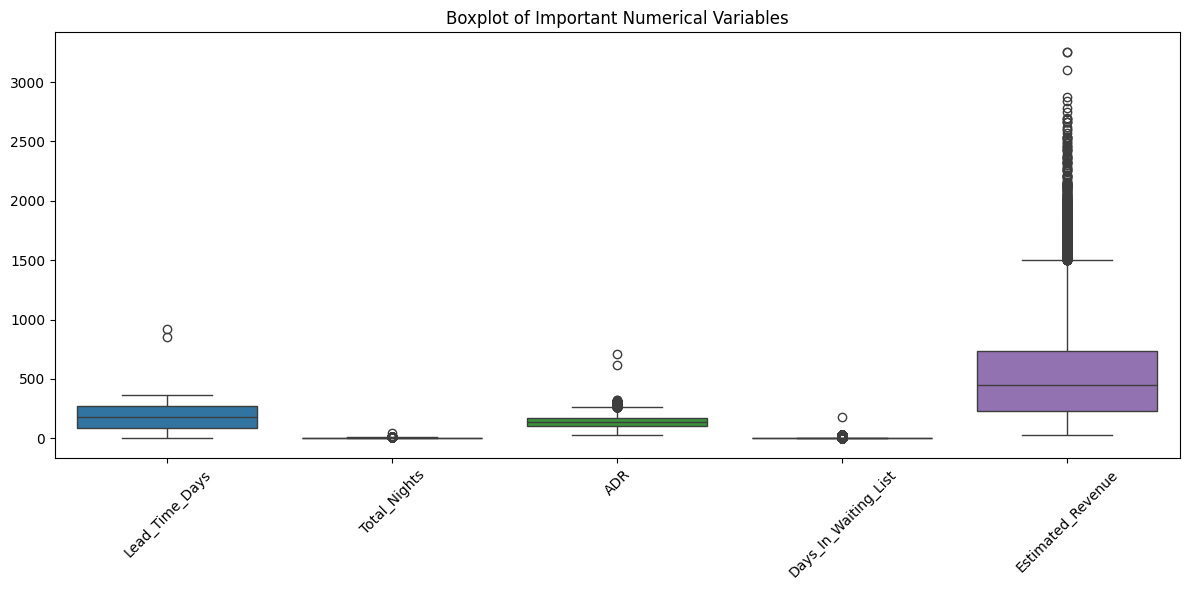

In [ ]:
# to Create boxplots for the selected numerical variables
plt.figure(figsize=(12, 6))
# to Plot the distributions of the selected variables
sns.boxplot(data=df[outlier_columns])
# to Add a title to the plot
plt.title('Boxplot of Important Numerical Variables')
# to Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# to Adjust the plot layout
plt.tight_layout()
# to Display the plot
plt.show()

In [ ]:
# Observation:
# The boxplots show that some variables contain values that extend noticeably beyond the main distribution.
# This indicates that potential outliers are present.
# these values may represent genuine hotel booking behavior, so we should investigate them before
# deciding whether they need to be removed or modified.

In [ ]:
# to Create an empty list to store outlier results
outlier_summary = []

for column in outlier_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    # to Calculate the interquartile range
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    outliers = df[
        (df[column] < lower_limit) |
        (df[column] > upper_limit)
    ]
    outlier_summary.append({
        'Column': column,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower_Limit': lower_limit,
        'Upper_Limit': upper_limit,
        'Outlier_Count': len(outliers),
        'Outlier_Percentage': (len(outliers) / len(df)) * 100
    })

# to Convert the outlier results into a DataFrame
outlier_summary = pd.DataFrame(outlier_summary)
outlier_summary

,Column,Q1,Q3,IQR,Lower_Limit,Upper_Limit,Outlier_Count,Outlier_Percentage
0,Lead_Time_Days,91.0000,273.000,182.0000,-182.00000,546.00000,2,0.008
1,Total_Nights,2.0000,5.000,3.0000,-2.50000,9.50000,136,0.544
2,ADR,105.6975,168.955,63.2575,10.81125,263.84125,360,1.440
3,Days_In_Waiting_List,0.0000,1.000,1.0000,-1.50000,2.50000,4082,16.328
4,Estimated_Revenue,230.6200,737.570,506.9500,-529.80500,1497.99500,652,2.608


In [ ]:
# to Check the 10 highest lead-time values
df['Lead_Time_Days'].nlargest(10)

,Lead_Time_Days
6729,920
16730,850
54,365
314,365
485,365
587,365
920,365
1021,365
1123,365
1395,365


In [ ]:
# to Check the 10 highest total-night values
df['Total_Nights'].nlargest(10)

,Total_Nights
12558,45
10648,13
21602,13
3883,12
15639,12
20756,12
23051,12
23490,12
328,11
1534,11


In [ ]:
# to Check the 10 highest ADR values
df['ADR'].nlargest(10)

,ADR
12103,710.50
8590,620.00
6582,325.96
9004,323.46
3204,316.81
14735,315.33
23928,314.26
14524,313.82
8742,312.70
17843,312.49


In [ ]:
# to Check the 10 highest estimated revenue values
df['Estimated_Revenue'].nlargest(10)

,Estimated_Revenue
10648,3256.02
16589,3254.89
8499,3100.95
4450,2876.03
15610,2843.63
8863,2778.54
23378,2752.06
15639,2694.62
12862,2691.33
7510,2686.78


In [ ]:
# to Check the number of rows and columns after cleaning
df.shape

(25000, 36)

In [ ]:
# to Check remaining duplicate records
df.duplicated().sum()

np.int64(0)

In [ ]:
# Observation:
# No exact duplicate records remain in the cleaned dataset.
# This confirms that the duplicate-removal step was successful.

In [ ]:
# to Check remaining missing values in all columns
df.isnull().sum()

,0
Booking_ID,0
Hotel_Type,0
Hotel_Location,105
Booking_Date,0
Arrival_Date,0
Lead_Time_Days,0
Weekend_Nights,0
Weekday_Nights,0
Adults,0
Children,0


In [ ]:
# to Check the data types of date columns after preprocessing
df[date_columns].dtypes

,0
Booking_Date,datetime64[ns]
Arrival_Date,datetime64[ns]
Reservation_Status_Date,datetime64[ns]


In [ ]:
# to Check cleaned hotel type categories
df['Hotel_Type'].value_counts()

,count
Hotel_Type,
City Hotel,15611
Resort Hotel,9389


In [ ]:
# to Check the data types of all columns after preprocessing
df.dtypes

,0
Booking_ID,object
Hotel_Type,string[python]
Hotel_Location,object
Booking_Date,datetime64[ns]
Arrival_Date,datetime64[ns]
Lead_Time_Days,int64
Weekend_Nights,int64
Weekday_Nights,int64
Adults,int64
Children,float64


In [ ]:
# to Check negative values in important numerical variables
numeric_check_columns = [
    'Lead_Time_Days',
    'Weekend_Nights',
    'Weekday_Nights',
    'Adults',
    'Children',
    'Babies',
    'Total_Nights',
    'ADR',
    'Days_In_Waiting_List',
    'Total_Special_Requests',
    'Satisfaction_Score',
    'Estimated_Revenue'
]

(df[numeric_check_columns] < 0).sum()

,0
Lead_Time_Days,0
Weekend_Nights,0
Weekday_Nights,0
Adults,0
Children,0
Babies,0
Total_Nights,0
ADR,0
Days_In_Waiting_List,0
Total_Special_Requests,0


In [ ]:
# to Display the final structure of the cleaned dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 25000 entries, 0 to 25179
Data columns (total 36 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Booking_ID                   25000 non-null  object        
 1   Hotel_Type                   25000 non-null  string        
 2   Hotel_Location               24895 non-null  object        
 3   Booking_Date                 25000 non-null  datetime64[ns]
 4   Arrival_Date                 25000 non-null  datetime64[ns]
 5   Lead_Time_Days               25000 non-null  int64         
 6   Weekend_Nights               25000 non-null  int64         
 7   Weekday_Nights               25000 non-null  int64         
 8   Adults                       25000 non-null  int64         
 9   Children                     25000 non-null  float64       
 10  Babies                       25000 non-null  int64         
 11  Country                      25000 non-null  o

In [ ]:
# Observation:
# The final data-quality checks indicate that the major preprocessing issues identified at the beginning have been addressed.
# The dataset is now in a cleaner and more consistent form.

In [ ]:
# to Generate descriptive statistics for numerical columns
df.describe()

,Booking_Date,Arrival_Date,Lead_Time_Days,Weekend_Nights,Weekday_Nights,Adults,Children,Babies,Is_Repeated_Guest,Previous_Cancellations,...,Days_In_Waiting_List,Total_Nights,ADR,Required_Car_Parking_Spaces,Total_Special_Requests,Satisfaction_Score,Is_Canceled,Reservation_Status_Date,Estimated_Revenue,Total_Guests
count,25000,25000,25000.000000,25000.000000,25000.00000,25000.000000,25000.00000,25000.00000,25000.000000,25000.000000,...,25000.000000,25000.000000,25000.000000,25000.00000,25000.000000,25000.000000,25000.000000,25000,25000.000000,25000.000000
mean,2025-01-01 02:16:03.072000,2025-07-02 05:55:37.344000,182.217400,1.240880,2.45000,2.198480,0.37068,0.04312,0.172880,0.038560,...,1.563280,3.692480,140.588141,0.22912,1.097800,3.854405,0.721760,2025-07-04 02:15:31.967999744,535.367978,2.612280
min,2024-01-01 00:00:00,2024-01-02 00:00:00,0.000000,0.000000,0.00000,1.000000,0.00000,0.00000,0.000000,0.000000,...,0.000000,1.000000,30.800000,0.00000,0.000000,0.300000,0.000000,2024-01-02 00:00:00,31.820000,1.000000
25%,2024-07-01 00:00:00,2024-12-30 00:00:00,91.000000,0.000000,1.00000,2.000000,0.00000,0.00000,0.000000,0.000000,...,0.000000,2.000000,105.697500,0.00000,0.000000,3.600000,0.000000,2025-01-01 00:00:00,230.620000,2.000000
50%,2024-12-30 12:00:00,2025-07-02 00:00:00,182.000000,1.000000,2.00000,2.000000,0.00000,0.00000,0.000000,0.000000,...,0.000000,4.000000,134.405000,0.00000,1.000000,3.860000,1.000000,2025-07-04 00:00:00,448.735000,2.000000
75%,2025-07-05 00:00:00,2026-01-03 00:00:00,273.000000,2.000000,4.00000,2.000000,1.00000,0.00000,0.000000,0.000000,...,1.000000,5.000000,168.955000,0.00000,2.000000,4.130000,1.000000,2026-01-05 00:00:00,737.570000,3.000000
max,2025-12-31 00:00:00,2026-12-29 00:00:00,920.000000,3.000000,13.00000,7.000000,6.00000,2.00000,1.000000,3.000000,...,180.000000,45.000000,710.500000,3.00000,5.000000,5.900000,1.000000,2026-12-30 00:00:00,3256.020000,8.000000
std,NaN,NaN,105.632493,1.064003,2.03007,0.662226,0.65679,0.22535,0.378151,0.250989,...,4.466228,2.085245,47.727032,0.53058,1.048179,0.403710,0.448141,NaN,389.640257,0.964567


In [ ]:
# to Compare mean and median for important numerical variables
df[
    ['Lead_Time_Days', 'Total_Nights', 'ADR', 'Days_In_Waiting_List',
     'Satisfaction_Score', 'Estimated_Revenue']
].agg(['mean', 'median']).T # .T - Transposes the result so that each variable appears as a row, making the table

,mean,median
Lead_Time_Days,182.217400,182.000
Total_Nights,3.692480,4.000
ADR,140.588141,134.405
Days_In_Waiting_List,1.563280,0.000
Satisfaction_Score,3.854405,3.860
Estimated_Revenue,535.367978,448.735


In [ ]:
# to Check the standard deviation of important numerical variables
df[
    ['Lead_Time_Days', 'Total_Nights', 'ADR',
     'Days_In_Waiting_List', 'Satisfaction_Score',
     'Estimated_Revenue']
].std()

,0
Lead_Time_Days,105.632493
Total_Nights,2.085245
ADR,47.727032
Days_In_Waiting_List,4.466228
Satisfaction_Score,0.403710
Estimated_Revenue,389.640257


In [ ]:
# to Generate descriptive statistics for categorical columns
df.describe(include='object')

,Booking_ID,Hotel_Location,Country,Room_Type_Reserved,Room_Type_Assigned,Deposit_Type,Agent_ID,Company_ID,Reservation_Status
count,25000,24895,25000,25000,25000,25000,25000,25000,25000
unique,25000,11,24,8,8,3,180,120,3
top,HTL011248,Lisbon,BRA,D,C,Non Refund,Not Specified,Not Specified,Canceled
freq,1,3148,1152,3207,3199,12401,300,20585,16606


In [ ]:
# to Count bookings by hotel type
df['Hotel_Type'].value_counts()

,count
Hotel_Type,
City Hotel,15611
Resort Hotel,9389


In [ ]:
# to Calculate the percentage of bookings by hotel type
hotel_booking_percentage = (
    df['Hotel_Type'].value_counts(normalize=True).mul(100).round(2)
)

hotel_booking_percentage

,proportion
Hotel_Type,
City Hotel,62.44
Resort Hotel,37.56


In [ ]:
# to Count bookings by cancellation status
df['Is_Canceled'].value_counts()

,count
Is_Canceled,
1,18044
0,6956


In [ ]:
# to Calculate the overall cancellation rate
cancellation_rate = df['Is_Canceled'].mean() * 100

cancellation_rate

np.float64(72.176)

In [ ]:
# Univariate Analysis - Univariate analysis means analyzing one variable at a time.

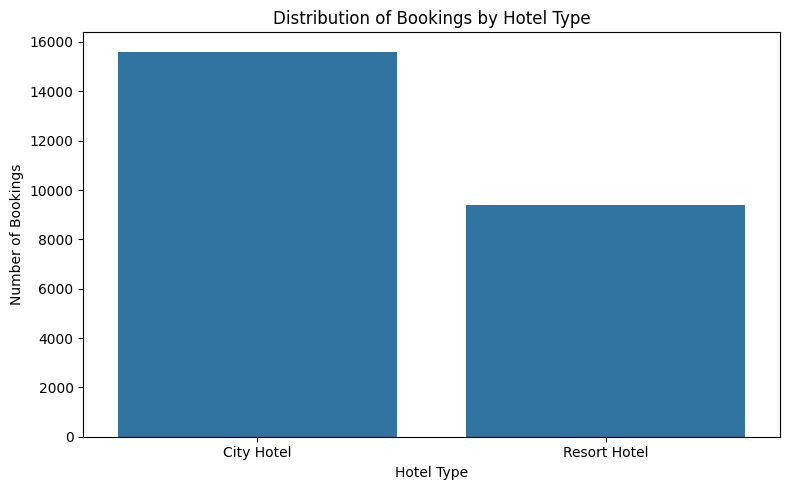

In [ ]:
# to Plot the number of bookings by hotel type
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x='Hotel_Type')

plt.title('Distribution of Bookings by Hotel Type')
plt.xlabel('Hotel Type')
plt.ylabel('Number of Bookings')

plt.tight_layout()
plt.show()

In [ ]:
# Observation:
# City Hotel has the highest number of bookings compared to the other hotel types.
# This shows that City Hotel is more popular among customers.

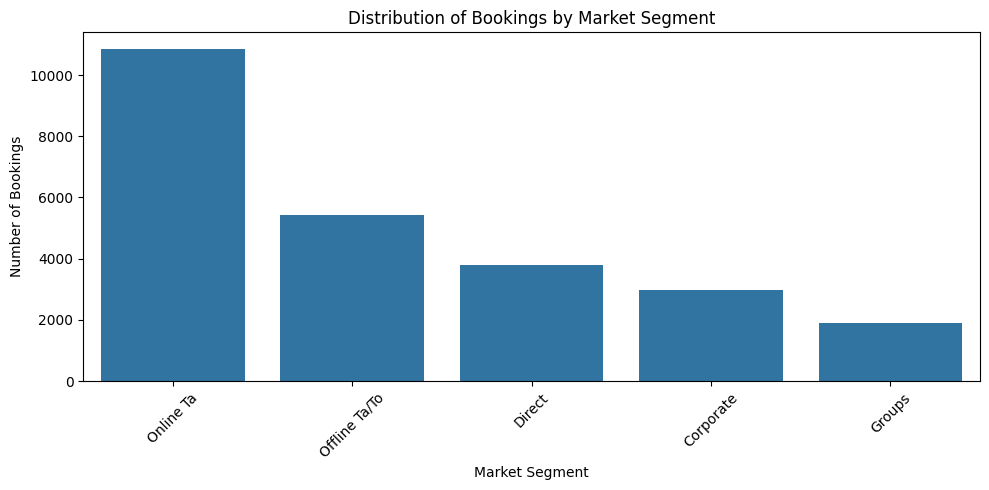

In [ ]:
# to Plot the number of bookings by market segment
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x='Market_Segment',
    order=df['Market_Segment'].value_counts().index
)

plt.title('Distribution of Bookings by Market Segment')
plt.xlabel('Market Segment')
plt.ylabel('Number of Bookings')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Observation:
# Online TA has the highest number of bookings among all market segments.
# This shows that online travel agencies are an important source of hotel bookings.

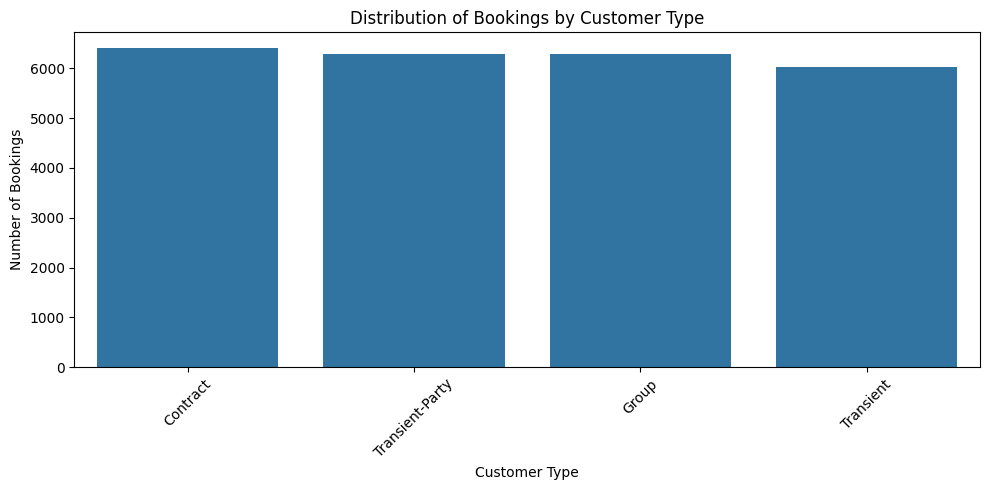

In [ ]:
# to Plot the number of bookings by customer type
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x='Customer_Type',
    order=df['Customer_Type'].value_counts().index
)

plt.title('Distribution of Bookings by Customer Type')
plt.xlabel('Customer Type')
plt.ylabel('Number of Bookings')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Observation:
# Contract customers have slightly more bookings than the other customer types.
# Overall, bookings are spread across different customer types.

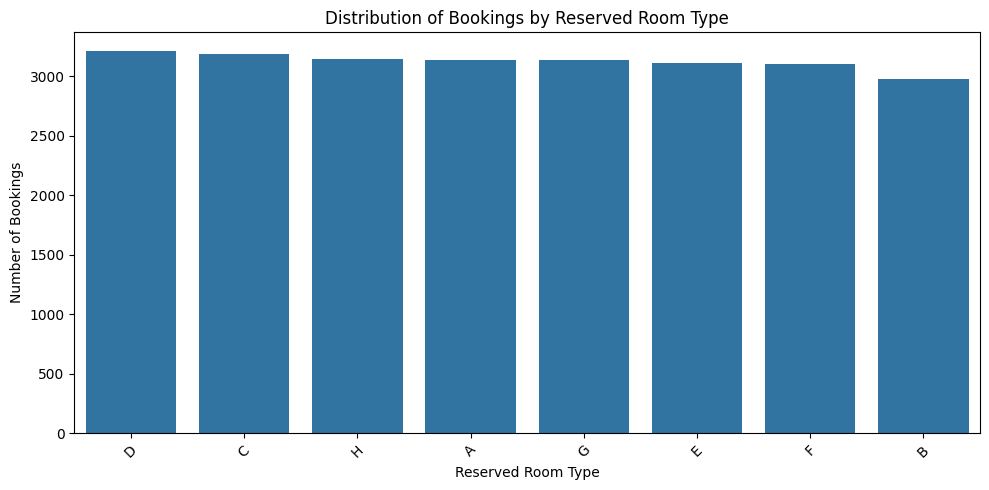

In [ ]:
# to Plot the number of bookings by reserved room type
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x='Room_Type_Reserved',
    order=df['Room_Type_Reserved'].value_counts().index
)

plt.title('Distribution of Bookings by Reserved Room Type')
plt.xlabel('Reserved Room Type')
plt.ylabel('Number of Bookings')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Observation:
# Room type D has the highest number of bookings, followed by other room types.
# The difference between the room types is not very large.

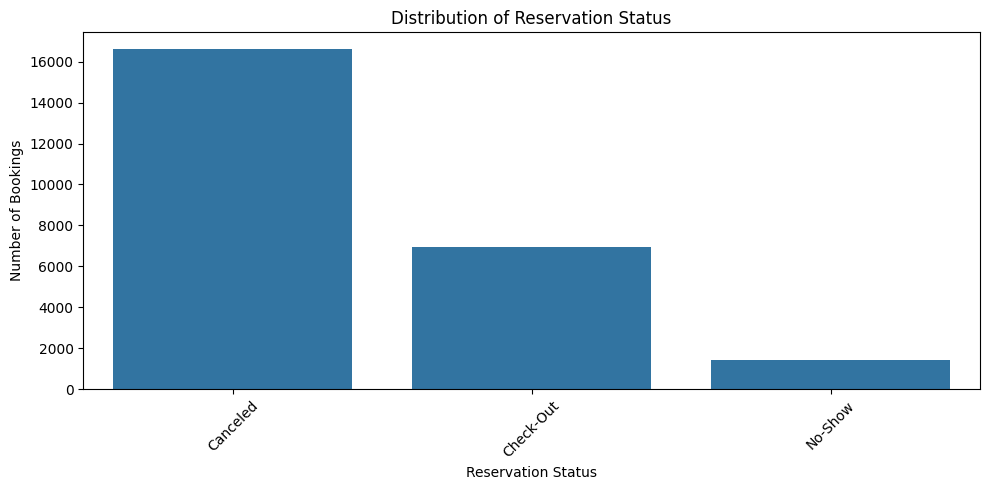

In [ ]:
# to Plot the number of bookings by reservation status
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x='Reservation_Status',
    order=df['Reservation_Status'].value_counts().index
)

plt.title('Distribution of Reservation Status')
plt.xlabel('Reservation Status')
plt.ylabel('Number of Bookings')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Observation:
# Canceled bookings are much higher than Check-Out and No-Show bookings.
# This shows that cancellations are a major issue in the dataset.

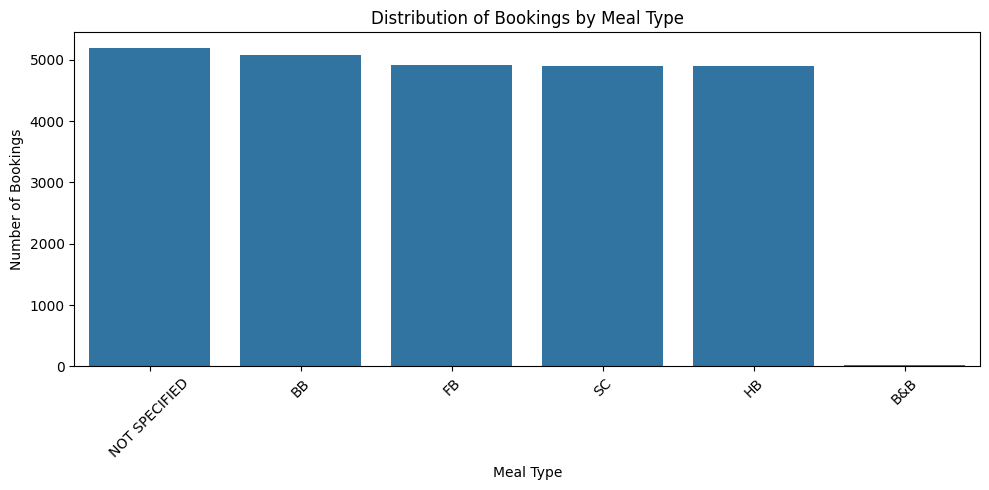

In [ ]:
# to Plot the number of bookings by meal type
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x='Meal_Type',
    order=df['Meal_Type'].value_counts().index
)

plt.title('Distribution of Bookings by Meal Type')
plt.xlabel('Meal Type')
plt.ylabel('Number of Bookings')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Observation:
# BB is the most common meal type among the bookings.
# Other meal types also have a significant number of bookings.

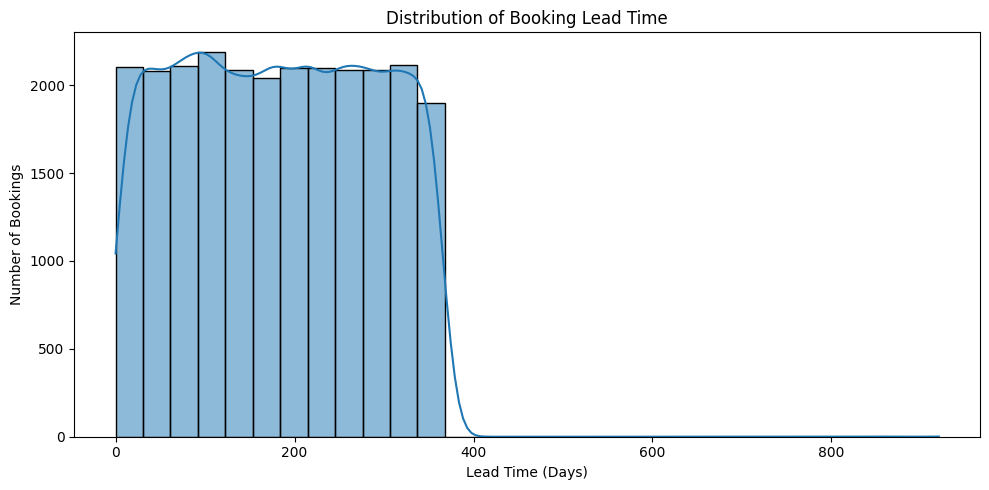

In [ ]:
# to Plot the distribution of booking lead time
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x='Lead_Time_Days',
    kde=True,
    bins=30
)

plt.title('Distribution of Booking Lead Time')
plt.xlabel('Lead Time (Days)')
plt.ylabel('Number of Bookings')

plt.tight_layout()
plt.show()

In [ ]:
# Observation:
# Most bookings are made several days in advance.
# A few bookings have very high lead times, creating a long right tail.

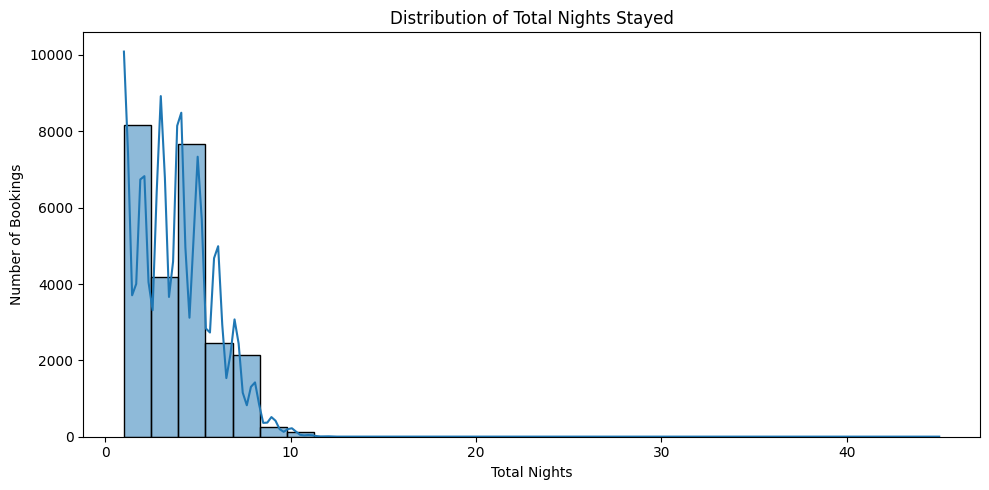

In [ ]:
# to Plot the distribution of total nights stayed
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x='Total_Nights',
    kde=True,
    bins=30
)

plt.title('Distribution of Total Nights Stayed')
plt.xlabel('Total Nights')
plt.ylabel('Number of Bookings')

plt.tight_layout()
plt.show()

In [ ]:
# Observation:
# Most customers stay for a few nights, mainly around 2 to 5 nights.
# Very long stays are less common.

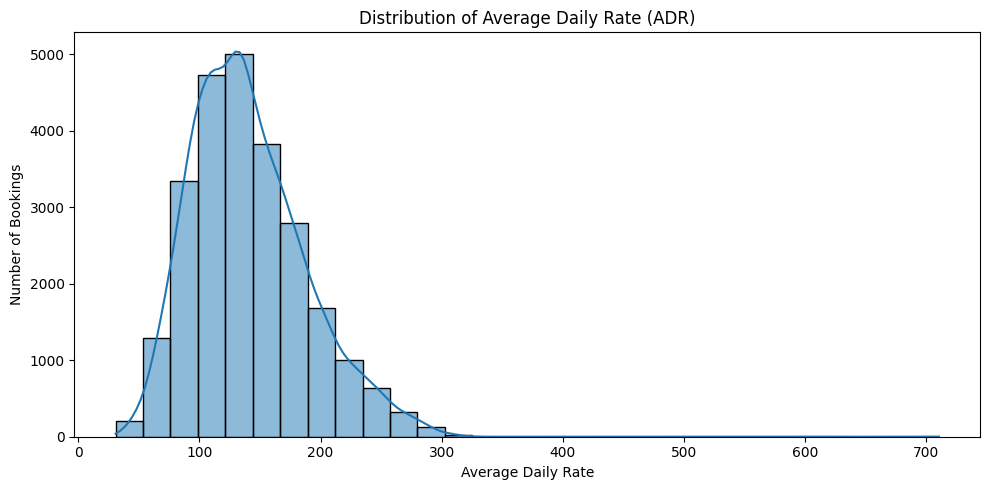

In [ ]:
# to Plot the distribution of average daily rate
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x='ADR',
    kde=True,
    bins=30
)

plt.title('Distribution of Average Daily Rate (ADR)')
plt.xlabel('Average Daily Rate')
plt.ylabel('Number of Bookings')

plt.tight_layout()
plt.show()

In [ ]:
# Observation:
# Most bookings have ADR values within a common price range.
# A few bookings have very high ADR values, creating a right-skewed distribution.

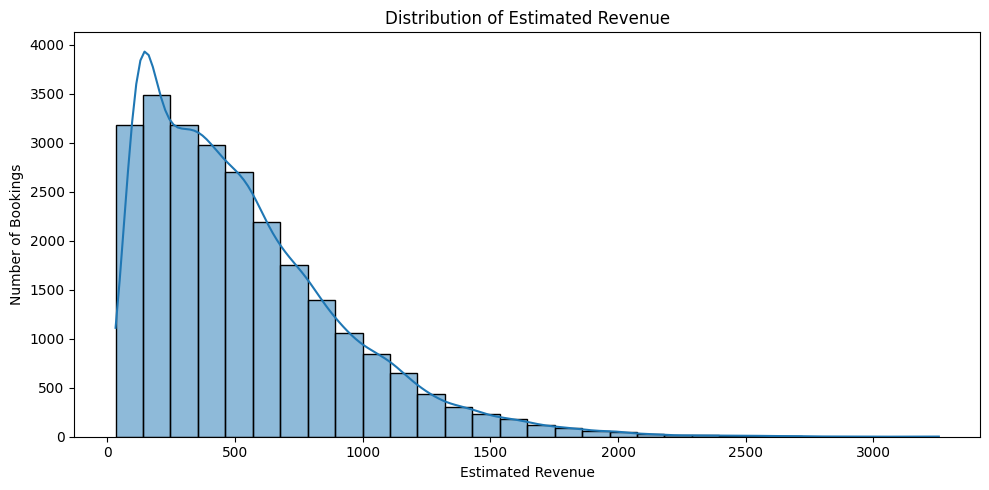

In [ ]:
# to Plot the distribution of estimated revenue
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x='Estimated_Revenue',
    kde=True,
    bins=30
)

plt.title('Distribution of Estimated Revenue')
plt.xlabel('Estimated Revenue')
plt.ylabel('Number of Bookings')

plt.tight_layout()
plt.show()

In [ ]:
# Observation:
# Most bookings generate low to moderate revenue.
# A small number of bookings generate much higher revenue.

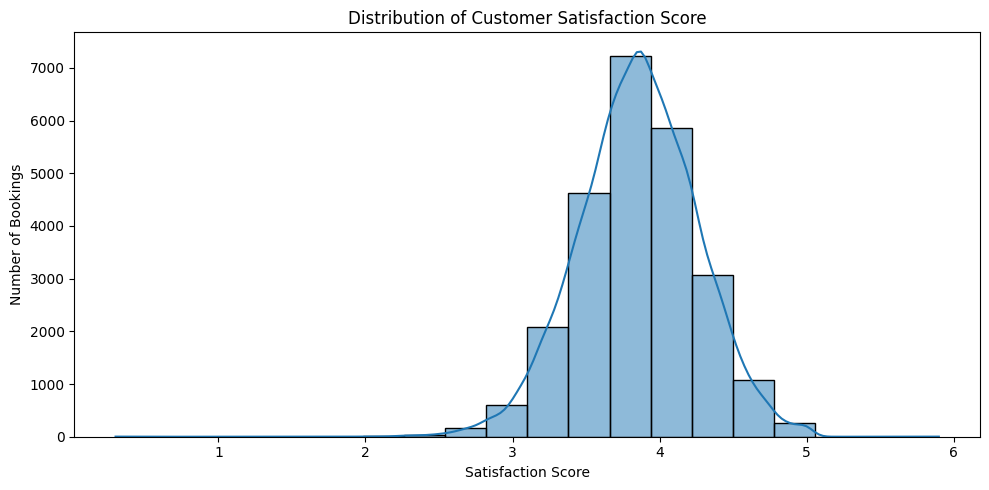

In [ ]:
# to Plot the distribution of customer satisfaction scores
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x='Satisfaction_Score',
    kde=True,
    bins=20
)

plt.title('Distribution of Customer Satisfaction Score')
plt.xlabel('Satisfaction Score')
plt.ylabel('Number of Bookings')

plt.tight_layout()
plt.show()

In [ ]:
# Observation:
# Most customers have moderate to high satisfaction scores.
# The scores are mainly concentrated around the middle to higher range.

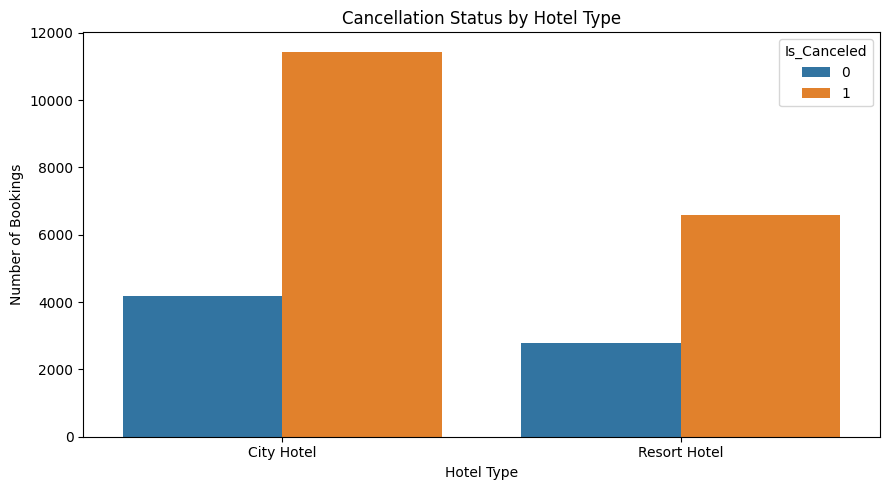

In [ ]:
# to Compare cancellation status across hotel types
plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x='Hotel_Type',
    hue='Is_Canceled'
)

plt.title('Cancellation Status by Hotel Type')
plt.xlabel('Hotel Type')
plt.ylabel('Number of Bookings')

plt.tight_layout()
plt.show()

In [ ]:
# Observation:
# City Hotel has more canceled bookings than Resort Hotel.
# City Hotel also has a higher overall number of bookings.
# In both hotel types, canceled bookings are higher than non-canceled bookings.
# This shows that cancellations are a major issue for both hotel types.

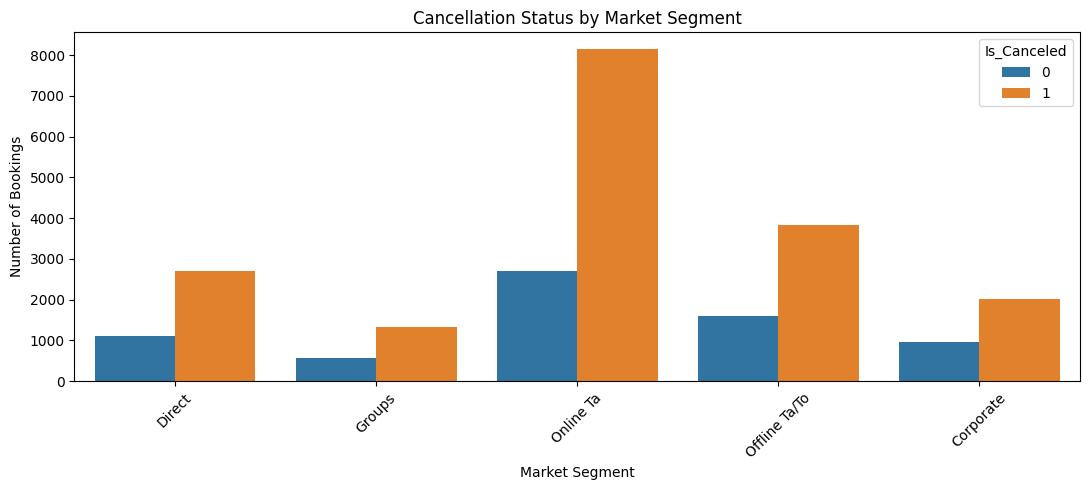

In [ ]:
# to Compare cancellation status across market segments
plt.figure(figsize=(11, 5))

sns.countplot(
    data=df,
    x='Market_Segment',
    hue='Is_Canceled'
)

plt.title('Cancellation Status by Market Segment')
plt.xlabel('Market Segment')
plt.ylabel('Number of Bookings')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Observation:
# Online TA has the highest number of canceled bookings.
# Online TA also has the highest number of non-canceled bookings.
# Offline TA/TO has the second highest number of bookings.
# Groups has the lowest number of bookings among the major market segments.
# Overall, Online TA contributes the largest share of both canceled and non-canceled bookings.

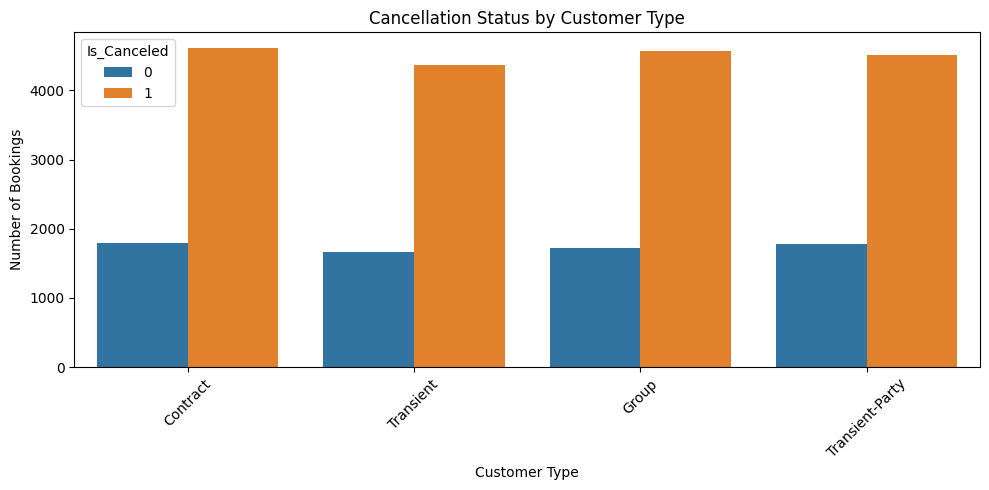

In [ ]:
# to Compare cancellation status across customer types
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x='Customer_Type',
    hue='Is_Canceled'
)

plt.title('Cancellation Status by Customer Type')
plt.xlabel('Customer Type')
plt.ylabel('Number of Bookings')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

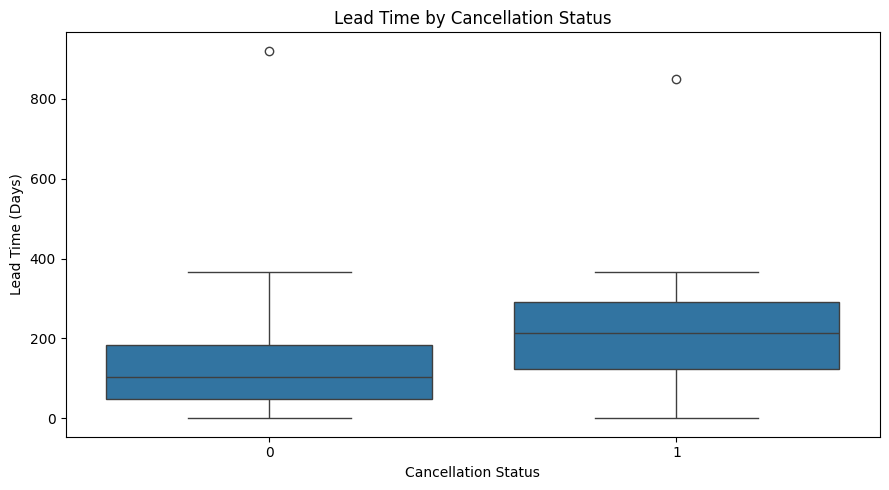

In [ ]:
# to Compare lead time across cancellation status
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x='Is_Canceled',
    y='Lead_Time_Days'
)

plt.title('Lead Time by Cancellation Status')
plt.xlabel('Cancellation Status')
plt.ylabel('Lead Time (Days)')

plt.tight_layout()
plt.show()

In [ ]:
# Observation:
# Canceled bookings generally have a higher lead time than non-canceled bookings.
# The canceled group shows a wider spread in lead time.
# This suggests that bookings made well in advance are more likely to be canceled.

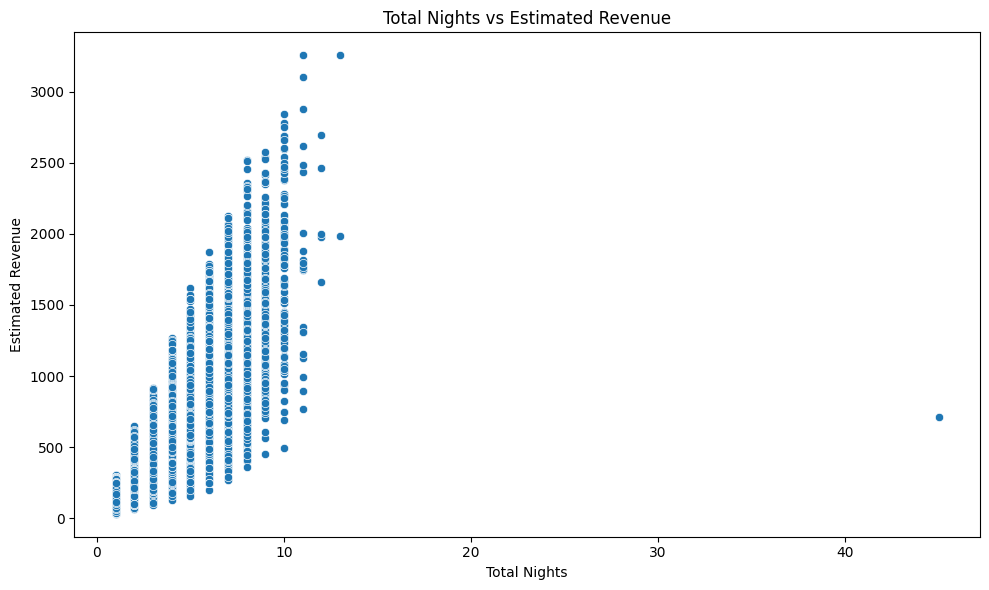

In [ ]:
# to Plot the relationship between total nights and estimated revenue
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='Total_Nights',
    y='Estimated_Revenue'
)

plt.title('Total Nights vs Estimated Revenue')
plt.xlabel('Total Nights')
plt.ylabel('Estimated Revenue')

plt.tight_layout()
plt.show()

In [ ]:
# Observation:
# Estimated revenue generally increases as the total number of nights increases.
# Most bookings have fewer than 10 total nights.
# There are a few unusual points with very high total nights or revenue.

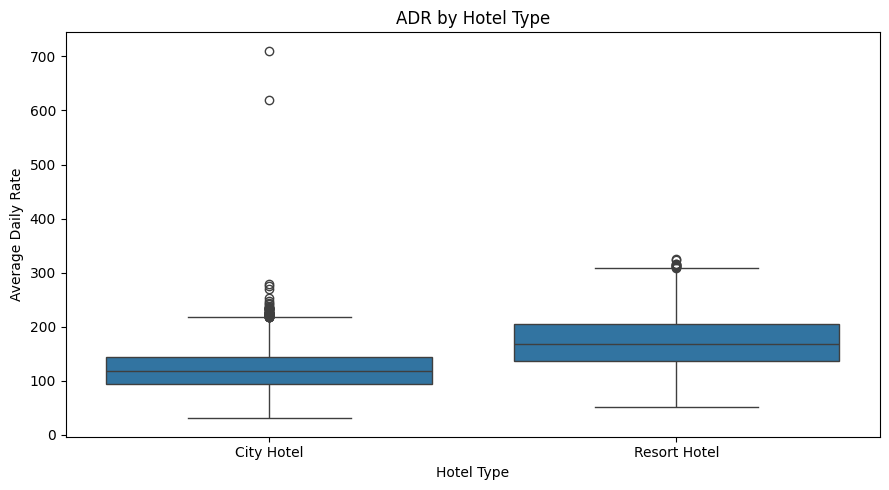

In [ ]:
# to Compare ADR across different hotel types
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x='Hotel_Type',
    y='ADR'
)

plt.title('ADR by Hotel Type')
plt.xlabel('Hotel Type')
plt.ylabel('Average Daily Rate')

plt.tight_layout()
plt.show()

In [ ]:
# Observation:
# Resort Hotel has a higher ADR than City Hotel.
# City Hotel has more extreme high-value ADR outliers.
# This shows that Resort Hotel generally has higher daily room rates.

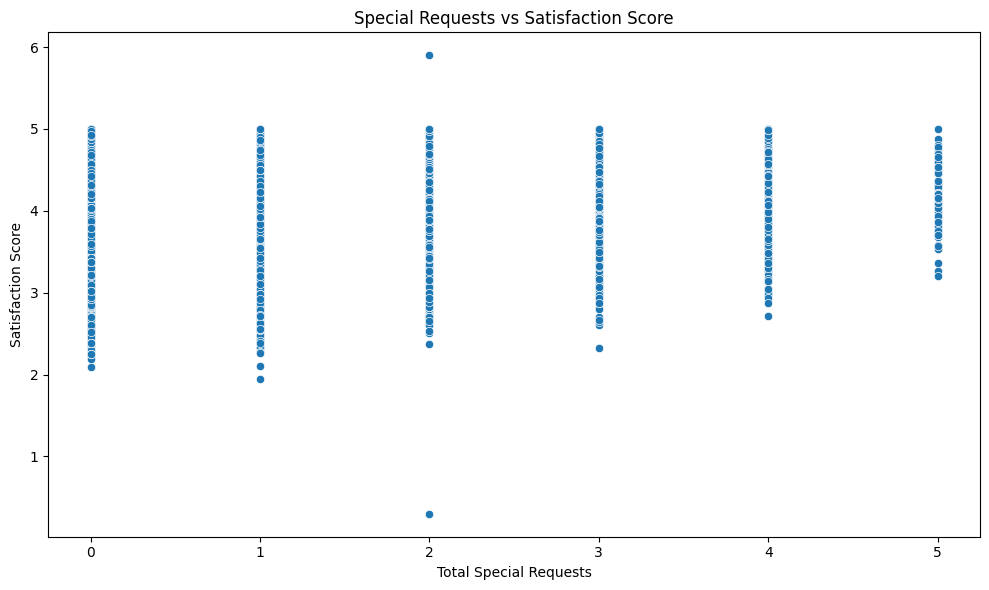

In [ ]:
# to Plot the relationship between special requests and satisfaction score
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='Total_Special_Requests',
    y='Satisfaction_Score'
)

plt.title('Special Requests vs Satisfaction Score')
plt.xlabel('Total Special Requests')
plt.ylabel('Satisfaction Score')

plt.tight_layout()
plt.show()

In [ ]:
# Observation:
# Satisfaction scores are generally moderate to high across all levels of special requests.
# There is no clear strong relationship between special requests and satisfaction score.
# Most satisfaction scores are concentrated between 3 and 5.
# A few unusual satisfaction scores can be seen as outliers.

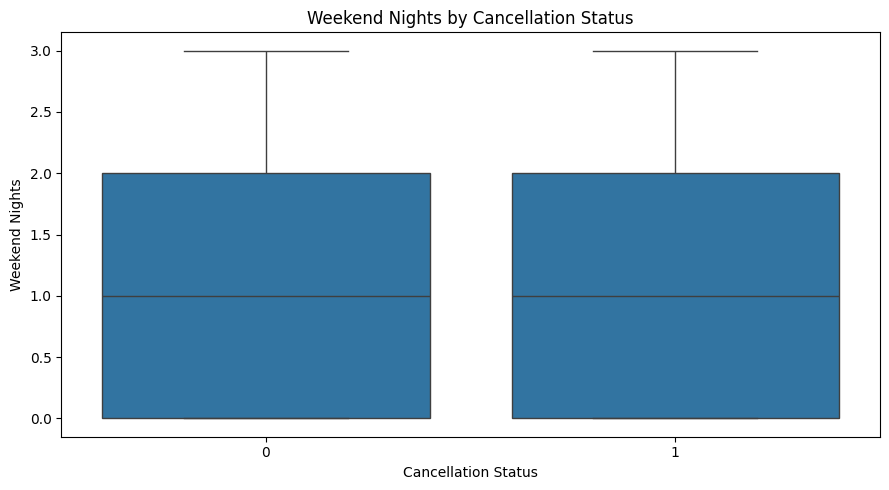

In [ ]:
# to Compare weekend nights across cancellation status
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x='Is_Canceled',
    y='Weekend_Nights'
)

plt.title('Weekend Nights by Cancellation Status')
plt.xlabel('Cancellation Status')
plt.ylabel('Weekend Nights')

plt.tight_layout()
plt.show()

In [ ]:
# to Calculate booking, ADR, revenue, and satisfaction metrics by hotel type
hotel_type_analysis = df.groupby('Hotel_Type').agg(
    Booking_Count=('Booking_ID', 'count'),
    Average_ADR=('ADR', 'mean'),
    Average_Revenue=('Estimated_Revenue', 'mean'),
    Average_Satisfaction=('Satisfaction_Score', 'mean')
).round(2)

# to Display the hotel type-wise analysis
hotel_type_analysis

,Booking_Count,Average_ADR,Average_Revenue,Average_Satisfaction
Hotel_Type,,,,
City Hotel,15611,120.76,385.52,3.85
Resort Hotel,9389,173.56,784.52,3.86


In [ ]:
# to Calculate booking, ADR, revenue, and cancellation metrics by market segment
market_segment_analysis = df.groupby('Market_Segment').agg(
    Booking_Count=('Booking_ID', 'count'),
    Average_ADR=('ADR', 'mean'),
    Average_Revenue=('Estimated_Revenue', 'mean'),
    Cancellation_Rate=('Is_Canceled', 'mean')
).round(2)

# to Convert cancellation rate into percentage
market_segment_analysis['Cancellation_Rate'] = (
    market_segment_analysis['Cancellation_Rate'] * 100
).round(2)

# to Display the market segment-wise analysis
market_segment_analysis

,Booking_Count,Average_ADR,Average_Revenue,Cancellation_Rate
Market_Segment,,,,
Corporate,2990,134.16,499.20,67.0
Direct,3808,143.25,550.96,71.0
Groups,1910,125.32,480.23,70.0
Offline Ta/To,5440,142.39,541.23,70.0
Online Ta,10852,143.21,546.63,75.0


In [ ]:
# to Calculate booking, ADR, revenue, and cancellation metrics by customer type
customer_type_analysis = df.groupby('Customer_Type').agg(
    Booking_Count=('Booking_ID', 'count'),
    Average_ADR=('ADR', 'mean'),
    Average_Revenue=('Estimated_Revenue', 'mean'),
    Cancellation_Rate=('Is_Canceled', 'mean')
).round(2)

# to Convert cancellation rate into percentage
customer_type_analysis['Cancellation_Rate'] = (
    customer_type_analysis['Cancellation_Rate'] * 100
).round(2)

# to Display the customer type-wise analysis
customer_type_analysis

,Booking_Count,Average_ADR,Average_Revenue,Cancellation_Rate
Customer_Type,,,,
Contract,6403,140.72,540.53,72.0
Group,6283,140.61,533.98,73.0
Transient,6027,141.16,539.42,72.0
Transient-Party,6287,139.88,527.61,72.0


In [ ]:
# to Select numerical columns for correlation analysis
correlation_columns = [
    'Lead_Time_Days',
    'Weekend_Nights',
    'Weekday_Nights',
    'Adults',
    'Children',
    'Babies',
    'Total_Nights',
    'ADR',
    'Days_In_Waiting_List',
    'Total_Special_Requests',
    'Satisfaction_Score',
    'Estimated_Revenue'
]

# to Calculate the correlation matrix
correlation_matrix = df[correlation_columns].corr()

# to Display the correlation matrix
correlation_matrix

,Lead_Time_Days,Weekend_Nights,Weekday_Nights,Adults,Children,Babies,Total_Nights,ADR,Days_In_Waiting_List,Total_Special_Requests,Satisfaction_Score,Estimated_Revenue
Lead_Time_Days,1.000000,-0.001751,-0.008347,-0.008730,0.002784,-0.001814,-0.009094,-0.000393,0.004302,0.002609,-0.007979,-0.008280
Weekend_Nights,-0.001751,1.000000,-0.225285,0.005720,-0.009172,0.002725,0.292198,0.050409,0.013198,0.001078,0.010451,0.237120
Weekday_Nights,-0.008347,-0.225285,1.000000,-0.002258,-0.002945,-0.011201,0.858418,0.144782,0.006574,-0.009197,0.003265,0.736105
Adults,-0.008730,0.005720,-0.002258,1.000000,0.010548,0.004299,0.000490,-0.003747,-0.006762,0.002058,-0.002316,-0.000634
Children,0.002784,-0.009172,-0.002945,0.010548,1.000000,-0.002593,-0.005643,0.004173,0.006874,0.002016,0.000865,-0.000125
Babies,-0.001814,0.002725,-0.011201,0.004299,-0.002593,1.000000,-0.009661,-0.006485,0.000190,0.008056,-0.000180,-0.009804
Total_Nights,-0.009094,0.292198,0.858418,0.000490,-0.005643,-0.009661,1.000000,0.166698,0.012866,-0.009208,0.008027,0.837965
ADR,-0.000393,0.050409,0.144782,-0.003747,0.004173,-0.006485,0.166698,1.000000,-0.002044,-0.003002,-0.001160,0.602987
Days_In_Waiting_List,0.004302,0.013198,0.006574,-0.006762,0.006874,0.000190,0.012866,-0.002044,1.000000,-0.005573,-0.275568,0.010958
Total_Special_Requests,0.002609,0.001078,-0.009197,0.002058,0.002016,0.008056,-0.009208,-0.003002,-0.005573,1.000000,0.202820,-0.010813


In [ ]:
# Observation:
# Total_Nights has a strong positive relationship with Estimated_Revenue.
# Weekday_Nights also has a strong positive relationship with Total_Nights and Estimated_Revenue.
# ADR has a moderate positive relationship with Estimated_Revenue.
# Most other variables have very weak correlations with each other.
# This shows that the length of stay and daily room rate are the main factors related to estimated revenue.

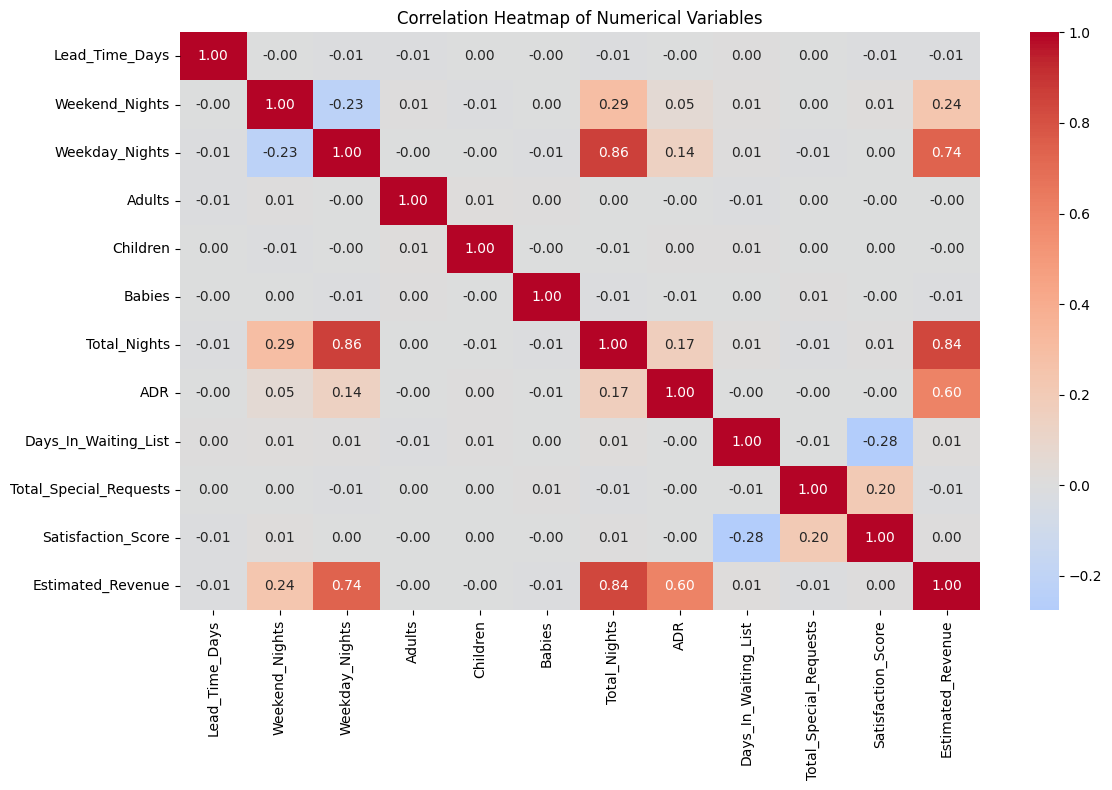

In [ ]:
# to Create a heatmap of the correlation matrix
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

# to Add a title to the heatmap
plt.title('Correlation Heatmap of Numerical Variables')

# to Adjust the plot layout
plt.tight_layout()

# to Display the heatmap
plt.show()

In [ ]:
# Observation:
# The heatmap shows that Total_Nights and Estimated_Revenue have a strong positive relationship.
# Weekday_Nights also has a strong positive relationship with Total_Nights and Estimated_Revenue.
# ADR has a moderate positive relationship with Estimated_Revenue.
# Most other variables have very weak relationships with each other.
# Overall, length of stay and ADR are the variables most closely related to estimated revenue.